In [ ]:
"""SETUP E CARICAMENTO DATI"""

import json
import urllib.request
from pathlib import Path
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# 1. Caricamento Dataset
DATA_URL = "https://raw.githubusercontent.com/Profession-AI/progetti-deeplearning/refs/heads/main/Sintesi%20automatica%20di%20cartelle%20cliniche%20di%20un%E2%80%99azienda%20ospedaliera/hospital_records.json"
INPUT_PATH = Path("hospital_records.json")

if not INPUT_PATH.exists():
    urllib.request.urlretrieve(DATA_URL, INPUT_PATH.as_posix())

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    records = json.load(f)

print(f"Dati caricati: trovati {len(records)} pazienti.")

Dati caricati: trovati 10 pazienti.


In [ ]:
"""INIZIALIZZAZIONE DEL MODELLO E FUNZIONI BASE"""

print("Caricamento del modello BART in corso...")
MODEL_NAME = "facebook/bart-large-cnn"

# Configurazione device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Caricamento esplicito (soluzione al bug della pipeline attenzionato anche al coach Zappa)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)

def format_hospitalization(hosp: dict) -> str:
    """Formatta un singolo ricovero estraendo i fatti salienti."""
    diagnosis = hosp.get("diagnosis", "Unknown")
    anamnesis = hosp.get("anamnesis", "None")
    prognosis = hosp.get("prognosis", "Unknown")
    meds = ", ".join(hosp.get("medications", []))
    tests = ", ".join(hosp.get("test_results", []))

    text = f"The patient was diagnosed with {diagnosis}. Anamnesis reveals {anamnesis}. "
    text += f"The prognosis is {prognosis}. "
    if meds: text += f"Medications administered include {meds}. "
    if tests: text += f"Test results showed {tests}. "
    return text.strip()

def safe_summarize(text: str, max_len: int = 100, min_len: int = 30) -> str:
    """Genera il riassunto gestendo correttamente i limiti dei token."""
    # Se il testo analizzato è già  breve, non ha senso riassumerlo ulteriormente pertanto:
    if len(text.split()) < 40:
        return text

    try:
        inputs = tokenizer(text, return_tensors="pt", max_length=1024, truncation=True).to(device)
        with torch.no_grad():
            summary_ids = model.generate(
                **inputs,
                max_new_tokens=max_len,
                min_new_tokens=min_len,
                do_sample=False
            )
        return tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    except Exception as e:
        print(f"Errore durante la sintesi: {e}")
        return text

print(f"Modello caricato su: {device}")

Caricamento del modello BART in corso...


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Modello caricato su: cuda


In [ ]:
"""ESECUZIONE DELL'ALGORITMO MAP-REDUCE"""

original_lengths = []
summary_lengths = []
output_data = []

print("Avvio della sintesi Map-Reduce...")

for patient in records:
    name = patient.get("patient_name", "Paziente Sconosciuto")
    hospitalizations = patient.get("hospitalizations", [])

    mini_summaries = []
    original_text_full = ""

    for h in hospitalizations:
        hosp_text = format_hospitalization(h)
        original_text_full += hosp_text + " "

        # MAP: Riassunto del singolo ricovero
        mini_summary = safe_summarize(hosp_text, max_len=60, min_len=20)
        mini_summaries.append(mini_summary)

    # REDUCE: Unione dei mini riassunti e riassunto finale
    combined_summaries = " ".join(mini_summaries)
    final_summary = safe_summarize(combined_summaries, max_len=150, min_len=50)

    # Salvataggio delle lunghezze per il grafico finale
    original_lengths.append(len(original_text_full.split()))
    summary_lengths.append(len(final_summary.split()))

    output_data.append({"patient_name": name, "summary": final_summary})

# Scrittura del file JSON di output
with open("summarized_patients.json", "w", encoding="utf-8") as f:
    json.dump(output_data, f, indent=4)

print("Sintesi completata! Dati salvati in 'summarized_patients.json'.")

Avvio della sintesi Map-Reduce...
Sintesi completata! Dati salvati in 'summarized_patients.json'.



VALUTAZIONE QUALITATIVA: CONFRONTO ORIGINALE VS SINTESI

ID PAZIENTE 1: Patient 1
LUNGHEZZA ORIGINALE: 59 parole
LUNGHEZZA SINTESI: 23 parole
------------------------------
TESTO ORIGINALE (Estratto):
The patient was diagnosed with Pneumonia. Anamnesis reveals No relevant anamnesis. The prognosis is Requires further monitoring. Medications administered include Captopril, Prednisone, Ciprofloxacin, Ibuprofen. Test results showed CT scan shows inflammation. The patient was diagnosed with Bronchitis. Anamnesis reveals No prior conditions. The prognosis is Surgery recommended. Medications administe...

SINTESI GENERATA:
The patient was diagnosed with Bronchitis. Anamnesis reveals No prior conditions. Medications administered include Captopril, Prednisone, Ciprofloxacin, Ibuprofen. The patient wasdiagnosed with Pneumonia.

****************************************

ID PAZIENTE 2: Patient 2
LUNGHEZZA ORIGINALE: 99 parole
LUNGHEZZA SINTESI: 34 parole
------------------------------
TESTO ORIGI

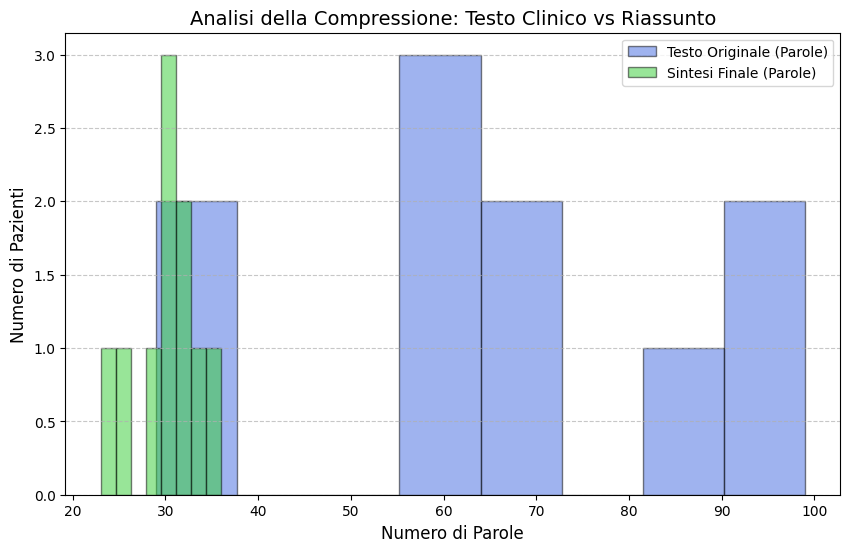

In [ ]:
"""Valutazione e Grafico"""

print("\n" + "="*70)
print("VALUTAZIONE QUALITATIVA: CONFRONTO ORIGINALE VS SINTESI")
print("="*70)

# Numero di campioni da mostrare
num_campioni = 3

for i in range(num_campioni):
    paziente_nome = records[i]['patient_name']

    # Ricostruzione del testo originale combinato per il confronto
    testo_originale = " ".join([format_hospitalization(h) for h in records[i]["hospitalizations"]])
    riassunto = output_data[i]["summary"]

    print(f"\nID PAZIENTE {i+1}: {paziente_nome}")
    print(f"LUNGHEZZA ORIGINALE: {len(testo_originale.split())} parole")
    print(f"LUNGHEZZA SINTESI: {len(riassunto.split())} parole")
    print("-" * 30)
    print(f"TESTO ORIGINALE (Estratto):\n{testo_originale[:400]}...")
    print(f"\nSINTESI GENERATA:\n{riassunto}")
    print("\n" + "*"*40)

print("\n" + "="*70)
print("VALUTAZIONE QUANTITATIVA: DISTRIBUZIONE LUNGHEZZE")
print("="*70)

# Creazione dell'istogramma
plt.figure(figsize=(10, 6))
plt.hist(original_lengths, bins=8, alpha=0.5, label='Testo Originale (Parole)', color='royalblue', edgecolor='black')
plt.hist(summary_lengths, bins=8, alpha=0.5, label='Sintesi Finale (Parole)', color='limegreen', edgecolor='black')

plt.title("Analisi della Compressione: Testo Clinico vs Riassunto", fontsize=14)
plt.xlabel("Numero di Parole", fontsize=12)
plt.ylabel("Numero di Pazienti", fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()